# Tarea 2
##Física computacional 2024-2

In [1]:
#Importamos las lbrerías que serán de utilidad
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math as mth

In [2]:
#Las funciones que nos ayudarán a calcular las raíces
def busqueda_incremental(f,a,b,h=1e-6):
    x0 = a
    x1 = a + h
    n = 0
    while f(x0)*f(x1)>0:
        x0 = x1
        x1 = x0 + h
        if x1>b:
            return('No hay raíz')
            break
        n += 1
    return [x1,n]

def biseccion(f,x0,x1,h=1e-6): #h el mínimo tamaño de paso
    x2 = (x0+x1)/2
    n = 0
    dx = abs(x0-x1)
    while dx>=h:
        if f(x0)*f(x2)<0:
            x1 = x2
            x2 = (x0+x1)/2
        elif f(x2)*f(x1)<0:
            x0 = x2
            x2 = (x0+x1)/2
        else:
            dx = h/2 ##break
            print('El intervalo no tiene raíz')
        dx = abs(x1-x0)
        n = n+1
    return [x1,n]

def newton_rhapson(f,df,x0,h=1e-6):
    dx = 2*h #intervalo para poder entrar al while,, dps lo vamos a redefinir
    n = 0
    while dx>h:
        x1 = x0 - (f(x0)/df(x0))
        dx = abs(x0-x1)
        x0 = x1
        n = n + 1
    return [x0,n]

def secante(f,x0,x1,h=1e-6):
    dx = 2*h
    n = 0
    while dx>h:
        x2 = x0 - ((x1-x0)/(f(x1)-f(x0)))*f(x0)
        dx = abs(x0-x1)
        x0 = x1
        x1 = x2
        n += 1
    return [x2,n,dx]

def ridders(f,x0,x1,h=1e-6):
    dx = abs(x0-x1)
    n = 0
    #Comenzamos con la parte de bisección
    x2 = (x0+x1)/2
    while dx>=h:
        if f(x0)*f(x2)<0:
            x1 = x2
            x2 = (x0+x1)/2
            #Ya determinamos el intervalo con el que trabajaremos para la siguiente parte. Ahora aplicamos el método de la secante.
            if f(x0)>f(x1): #caso decreciente
                x3 = x2 + (x2-x0)*(f(x2)/(mth.sqrt(f(x2)**2-f(x0)*f(x1))))
            elif f(x0)<f(x1): #caso creciente
                x3 = x2 - (x2-x0)*(f(x2)/(mth.sqrt(f(x2)**2-f(x0)*f(x1))))
                
        elif f(x2)*f(x1)<0:
            x0 = x2
            x2 = (x0+x1)/2
            #Ya determinamos el intervalo con el que trabajaremos para la siguiente parte. Ahora aplicamos el método de la secante.
            if f(x0)>f(x1): #caso decreciente
                x3 = x2 + (x2-x0)*(f(x2)/(mth.sqrt(f(x2)**2-f(x0)*f(x1))))
            elif f(x0)<f(x1): #caso creciente
                x3 = x2 - (x2-x0)*(f(x2)/(mth.sqrt(f(x2)**2-f(x0)*f(x1))))
        else:
            dx = h/2 ##break
            print('El intervalo no tiene raíz')
        dx = abs(x1-x0)
        n+=1
    return [x3,n,dx]

In [3]:
#Las funciones que nos ayudarán a calcular el error
def error_abs(real,approx):
    return abs(real-approx)
def error_rel(real,approx):
    return (abs(real-approx))/real
def error_por(real,approx):
    return ((abs(real-approx))/real)*100

In [4]:
#La función que nos ayuda a encontrar los polinomios de Lagrange
def lagrange(x,X,Y):
    if len(X)!=len(Y):
        return ('Vectores con dimensiones distintas')
    else:
        Points = list(zip(X,Y)) #aquí genero los puntos, con las listas dadas por el usuario
        Lk = [ ] #aquí guardo los poinomios de Lagrange
        n = len(X)
        for i in range(n): #índice lento
            l = 1
            for k in range(n): #índice rápido
                if k!=i: #ortonormalidad
                    l*=(x-X[k])/float(X[i]-X[k]) #este es el k-esimo polinomio de Lagrange
            Lk.append(l)
        polinomio = 0.0
        for i in range(n):
            polinomio +=Lk[i]*Y[i]
        return polinomio

tolerancia en el codigo: la épsilon, la mínima medida
la raíz será $x_2 = float \pm \epsilon$ 
con pandas calculabamos la presición con la tolerancia
al cambiar la tolerancia el error cambia 
$i(\epsilon) | x_2 | error porcentual$

Error total = error de punto flotante + error numérico

error de punto flotante 10e-16

## 1. VIGA VOLADIZA

Una viga voladiza es una estructura que esta soportada solo uno de sus lados. La ecuacion que describe la frecuencia de oscilacion de la viga es la siguiente:

$$ f(\beta) = \sinh(\beta)\sin(\beta) - 1. $$

Donde $f_{n}$ es la frecuencia n-ésima, $m$ la masa de la viga, $L$ la logitud de la viga, $E$ es la eslasticidad, $I$ el momento de inercia de la seccion transversal y $\beta_{n} = (2\pi f_{n})^{2} \frac{mL^{3}}{EI}$.

Supongamos que la viga en cuestión tiene las siguientes características:
$m = 4.41$ kg, $L = 0.9$ m, $E = 200x10^{9}$Pa e $I = 3.255 x10^{-8}$.

### a) Determina dos frecuencias para la viga tales que $f(\beta)=0$.
*Por favor verifica que las frecuencias tengan significado fisico.
Para que la sfrecuencias tengan sentido físico esta stienen que ser mayor o iguales a cero, así consideramos únicamente las primeras dos raíces de la función f.

De Wolfram Mathematica tenemos las siguientes raíces:

\begin{equation}
x_0 = 7.18237168241355121995393597
\end{equation}
\begin{equation}
x_1 = 12.4998023777515969714964485
\end{equation}

### b) Discute con tus propias palabras lo que sucedería si la viga lograra tales frecuencias.
Estas dos vibraciones corresponden a los primeros dos modos de vibración de la viga. El primero es el de menor frecuencia, por lo que puede ser considerado para construir vigas que se requiere que sean más estables; mientras que el segundo modo de vibración corresponde a uno de mayor movimiento de la viga por lo que puede ser útil para un análisis más dinámico de ésta.

### c) Usa todos los métodos que conoces y despliega los resultados con los errores totales correspondientes. Explica cuál es el mejor método y por qué. Además de, en cada método, indicar cómo se calcula el error.

Text(0.5, 1.0, 'Gráfica 1. Viga voladiza')

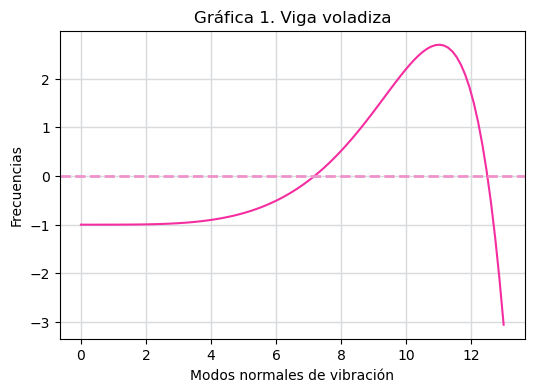

In [5]:
#Primero describimos el argumento beta
f_n = np.linspace(0,13,100)
m = 4.41 
L = 0.9
E = 200e9
I = 3.255e-8

def funcion_beta(fn):
    beta = (2*mth.pi*fn)**2*(m*L**3)/(E*I)
    f_beta = np.sinh(beta)*np.sin(beta)-1
    return f_beta

plt.figure(figsize=(6,4))
plt.plot(f_n,funcion_beta(f_n), color='#F42EA0')
plt.axhline(color='#EF91CB',linestyle='dashed',linewidth = 2)
plt.grid(color = '#D7DBDD',linewidth = 1)
plt.xlabel('Modos normales de vibración')
plt.ylabel('Frecuencias')
plt.title('Gráfica 1. Viga voladiza')


Podemos observar que la gráfica tiene ceros en los intervalos (5,10) y (10,13). Calculamos ahora ambas frecuencias con todos los métodos

In [6]:
#Definimos la derivada de f que usaremos para el método de Newton
df_beta = lambda beta: np.cosh(beta) * np.sin(beta) + np.sinh(beta) * np.cos(beta)

# Definición de beta 
beta_n = lambda fn: (2*mth.pi*fn)**2*(m*L**3)/(E*I)

# Derivada de beta con respecto a fn
d_beta_n = lambda fn: 4 * mth.pi * (m*L**3)/(E*I) * (2 * mth.pi) * fn

# Derivada de f(β) con respecto a fn
dfn = lambda fn: df_beta(beta_n(fn)) * d_beta_n(fn)

#Para el intervalo (5,10)
print('Raíz en (5,10)','\n')
print('Búsqueda incremental: ',busqueda_incremental(funcion_beta,5,10))
print('Bisección: ',biseccion(funcion_beta,5,10))
print('Newton Rhapson: ',newton_rhapson(funcion_beta,dfn,5))
print('Secante: ',secante(funcion_beta,5,10))
print('Ridders: ',ridders(funcion_beta,5,10))

print('\n','Raíz en (12,13)','\n')
print('Búsqueda incremental: ',busqueda_incremental(funcion_beta,10,13))
print('Bisección: ',biseccion(funcion_beta,10,13))
print('Newton Rhapson: ',newton_rhapson(funcion_beta,dfn,12))
print('Secante: ',secante(funcion_beta,10,13))
print('Ridders: ',ridders(funcion_beta,10,13))


Raíz en (5,10) 

Búsqueda incremental:  [7.1823720003050475, 2182371]
Bisección:  [7.182372212409973, 23]
Newton Rhapson:  [7.182371682413551, 6]
Secante:  [7.182371682413551, 8, 3.4015493532990604e-08]
Ridders:  [7.182371682413552, 23, 5.960464477539062e-07]

 Raíz en (12,13) 

Búsqueda incremental:  [12.499802998129146, 2499802]
Bisección:  [12.499803066253662, 22]
Newton Rhapson:  [12.499802377751601, 5]
Secante:  [12.499802377751596, 10, 4.5981587071253216e-07]
Ridders:  [12.499802377751598, 22, 7.152557373046875e-07]


In [7]:
#Ahora construimos el pandas para comparar los errores

incremental_raiz = []
incremental_pasos = []
incremental_error = []

biseccion_raiz = []
biseccion_pasos = []
biseccion_error = []

newton_raiz = []
newton_pasos = []
newton_error = []

secante_raiz = []
secante_pasos = []
secante_error = []

ridders_raiz = []
ridders_pasos = []
ridders_error = []

idx = []
valor_real=7.18237168241355121995393597 #valor obtenido con mathematica
for i in range(1,8):
    tol = 10**(-i)
    idx.append(tol)
    
    #Búsqueda incremental
    raiz_incremental=busqueda_incremental(funcion_beta,5,10,tol) #cada renglon de la tabla, cada método me arroja como resultado una lista por lo que este objeto es una lista
    errorbi = error_por(valor_real,raiz_incremental[0])
    incremental_raiz.append(raiz_incremental[0])
    incremental_pasos.append(raiz_incremental[1])
    incremental_error.append(errorbi)
    
    #Bisección
    raiz_biseccion=biseccion(funcion_beta,5,10,tol)
    errorb = error_por(valor_real,raiz_biseccion[0])
    biseccion_raiz.append(raiz_biseccion[0])
    biseccion_pasos.append(raiz_biseccion[1])
    biseccion_error.append(errorb)
    
    #Newton
    raiz_newton=newton_rhapson(funcion_beta,dfn,5,tol)
    errorn = error_por(valor_real,raiz_newton[0])
    newton_raiz.append(raiz_newton[0])
    newton_pasos.append(raiz_newton[1])
    newton_error.append(errorn)
    
    #Secante
    raiz_secante=secante(funcion_beta,5,10,tol)
    errors = error_por(valor_real,raiz_secante[0])
    secante_raiz.append(raiz_secante[0])
    secante_pasos.append(raiz_secante[1])
    secante_error.append(errors)
    
    #Ridders
    raiz_ridders=ridders(funcion_beta,5,10,tol)
    errorr = error_por(valor_real,raiz_ridders[0])
    ridders_raiz.append(raiz_incremental[0])
    ridders_pasos.append(raiz_incremental[1])
    ridders_error.append(errorbi)
    
cols = ['Búsqueda Incremental raiz','Búsqueda Incremental pasos','Búsqueda Incremental error',
        'Bisección raiz','Bisección pasos','Bisección error',
        'Newton-Rhapson raiz','Newton-Rhapson pasos','Newton-Rhapson error',
        'Secante raiz','Secante pasos','Secante error','Ridders raiz','Ridders pasos','Ridders error']
pd.DataFrame(list(zip(
incremental_raiz,
incremental_pasos,
incremental_error,
biseccion_raiz,
biseccion_pasos,
biseccion_error,
newton_raiz,
newton_pasos,
newton_error,
secante_raiz,
secante_pasos,
secante_error,
ridders_raiz,
ridders_pasos,
ridders_error)), index=idx, columns=cols)

#El error que se reporta es el error porcentual :D

,Búsqueda Incremental raiz,Búsqueda Incremental pasos,Búsqueda Incremental error,Bisección raiz,Bisección pasos,Bisección error,Newton-Rhapson raiz,Newton-Rhapson pasos,Newton-Rhapson error,Secante raiz,Secante pasos,Secante error,Ridders raiz,Ridders pasos,Ridders error
1.000000e-01,7.200000,21,2.454387e-01,7.187500,6,7.140145e-02,7.182429,4,8.014180e-04,7.182325,5,6.430895e-04,7.200000,21,2.454387e-01
1.000000e-02,7.190000,218,1.062089e-01,7.187500,9,7.140145e-02,7.182372,5,8.729333e-09,7.182372,6,4.735928e-07,7.190000,218,1.062089e-01
1.000000e-03,7.183000,2182,8.748052e-03,7.182617,13,3.418162e-03,7.182372,5,8.729333e-09,7.182372,7,4.142640e-12,7.183000,2182,8.748052e-03
1.000000e-04,7.182400,21823,3.942651e-04,7.182388,16,2.314451e-04,7.182372,5,8.729333e-09,7.182372,7,4.142640e-12,7.182400,21823,3.942651e-04
1.000000e-05,7.182380,218237,1.158044e-04,7.182379,19,9.866528e-05,7.182372,6,0.000000e+00,7.182372,8,0.000000e+00,7.182380,218237,1.158044e-04
1.000000e-06,7.182372,2182371,4.425996e-06,7.182372,23,7.379128e-06,7.182372,6,0.000000e+00,7.182372,8,0.000000e+00,7.182372,2182371,4.425996e-06
1.000000e-07,7.182372,21823716,3.300651e-07,7.182372,26,1.177296e-07,7.182372,6,0.000000e+00,7.182372,8,0.000000e+00,7.182372,21823716,3.300651e-07


## 2. EFICIENCIA DE UN MOTOR

La eficiencia del motor esta dada por la siguiente expresion:

$\eta = \frac{\ln(T_{2}/T_{1}) + (1 - T_{2}/T_{1})} {\ln(T_{2}/T_{1}) - (1 - T_{2}/T_{1})/(\gamma -1) }.$

### a) Encuentra el valor de $T_{2}$ que logra una eficiencia del 30%, considera $T_{1}$ = 400K, $\gamma = 5/3$. ¿Qué tipo de gas hace funcionar al motor?
De mathematica el valor real es $T_2 = 73.9023436207940$ y el coeficiente $ \gamma = \frac{5}{3}$ corresponde a un gas monoatómico

### b) Repite el proceso para $\gamma = 7/5$.
De mathematica el valor real es $T_2 = 42.9420985563164$

### c) Realiza una gráfica donde muestres la variación de la eficiencia al aumentar $T_{2}$. Discute la grafica y el significado físico del sistema.
Al aumentar la temperatura la eficiencia del sistema disminuye, lo cual tiene sentido ya que quiere decir que el calor que se le aplica al motor está siendo disipado en mayor medida obteniendo menor trabajo como ganancia.

### d) Usa todos los métodos que conoces y despliega los resultados con los errores totales correspondientes. Explica cuál es el mejor método y por qué. Además de, en cada método, indicar cómo se calcula el error.

In [8]:
#Definimos la función que nos ayudará a obtener la temperatura
def temp2(T2):
    eficiencia = 0.3
    T1 = 400
    gamma = 5/3
    cociente = T2/T1
    f_T2 = (np.log(cociente)+(1-cociente))/(np.log(cociente)-(1-cociente)/(gamma-1))-eficiencia
    return f_T2

def derivada_T2(T2):
    d_T2 = (-1600000+4000*T2-4000*T2*np.log(T2)+4000*np.log(400)*T2)/(T2*(800*np.log(T2)-800*np.log(400-1200+3*T2)**2))
    return d_T2

[73.90234362079399, 7, 7.720398116362048e-07] 	


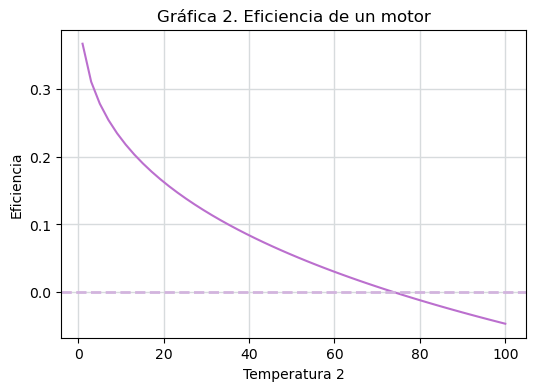

In [9]:
#Ahora calculamos un gráfico para ubicar las raíces
T2 = np.linspace(1,100)
plt.figure(figsize=(6,4))
plt.plot(T2,temp2(T2), color='#BB6FCE')
plt.axhline(color='#D2B4DE',linestyle='dashed',linewidth = 2)
plt.grid(color = '#D7DBDD',linewidth = 1)
plt.xlabel('Temperatura 2')
plt.ylabel('Eficiencia')
plt.title('Gráfica 2. Eficiencia de un motor')

#Utilizamos secante para aproximar un valor
print(secante(temp2,1,100),'\t')

In [10]:
#Ahora utilizamos todos los métodos
print('Raíz','\n', busqueda_incremental(temp2,60,80))
print(biseccion(temp2,1,100))
#print(newton_rhapson(temp2,derivada_T2,60))
print(secante(temp2,1,100))
print(ridders(temp2,1,100))

Raíz 
 [73.90234396489996, 13902343]
[73.90234392881393, 27]
[73.90234362079399, 7, 7.720398116362048e-07]
[73.902343620794, 27, 7.37607479095459e-07]


#Calculamos el error con pandas

incremental_raiz = []
incremental_pasos = []
incremental_error = []

biseccion_raiz = []
biseccion_pasos = []
biseccion_error = []

newton_raiz = []
newton_pasos = []
newton_error = []

secante_raiz = []
secante_pasos = []
secante_error = []

ridders_raiz = []
ridders_pasos = []
ridders_error = []

idx = []
valor_real=7.18237168241355121995393597 #valor obtenido con mathematica
for i in range(1,8):
    tol = 10**(-i)
    idx.append(tol)
    
    #Búsqueda incremental
    raiz_incremental=busqueda_incremental(temp2,1,100,tol) #cada renglon de la tabla, cada método me arroja como resultado una lista por lo que este objeto es una lista
    errorbi = error_por(valor_real,raiz_incremental[0])
    incremental_raiz.append(raiz_incremental[0])
    incremental_pasos.append(raiz_incremental[1])
    incremental_error.append(errorbi)
    
    #Bisección
    raiz_biseccion=biseccion(temp2,1,100,tol)
    errorb = error_por(valor_real,raiz_biseccion[0])
    biseccion_raiz.append(raiz_biseccion[0])
    biseccion_pasos.append(raiz_biseccion[1])
    biseccion_error.append(errorb)
    
    '''
        Newton
    raiz_newton=newton_rhapson(temp2,derivada_temp2,60,tol)
    errorn = error_por(valor_real,raiz_newton[0])
    newton_raiz.append(raiz_newton[0])
    newton_pasos.append(raiz_newton[1])
    newton_error.append(errorn)
    '''

    #Secante
    raiz_secante=secante(temp2,1,100,tol)
    errors = error_por(valor_real,raiz_secante[0])
    secante_raiz.append(raiz_secante[0])
    secante_pasos.append(raiz_secante[1])
    secante_error.append(errors)
    
    #Ridders
    raiz_ridders=ridders(temp2,1,100,tol)
    errorr = error_por(valor_real,raiz_ridders[0])
    ridders_raiz.append(raiz_incremental[0])
    ridders_pasos.append(raiz_incremental[1])
    ridders_error.append(errorbi)
    
cols = ['Búsqueda Incremental raiz','Búsqueda Incremental pasos','Búsqueda Incremental error',
        'Bisección raiz','Bisección pasos','Bisección error',
        'Secante raiz','Secante pasos','Secante error','Ridders raiz','Ridders pasos','Ridders error']
pd.DataFrame(list(zip(
incremental_raiz,
incremental_pasos,
incremental_error,
biseccion_raiz,
biseccion_pasos,
biseccion_error,
secante_raiz,
secante_pasos,
secante_error,
ridders_raiz,
ridders_pasos,
ridders_error)), index=idx, columns=cols)

#El error que se reporta es el error porcentual :D

# 3. FLUJO DE UN FLUÍDO

La ecuación de Bernoulli para el flujo de un fluido en un canal abierto con una pequeña protuberancia es:
$$
\frac{Q^2}{2gb^2h_0^2}+h_0=\frac{Q^2}{2gb^2h^2}+h+H
$$

donde:
\begin{eqnarray*}
	Q &=& 1.2\; m^3/s= \text{tasa de volumen de flujo}\\
	g &=& 9.81\; m/s^2= \text{aceleración de la gravedad}\\
	b &=& 1.8 \; m = \text{ancho del canal}\\
	h_0 &=& 0.6 \; m = \text{nivel de agua}\\
	H &=& 0.075 \; m =\text{ altura de protuberancia}\\
	h &=& \text{ h a determinar}
\end{eqnarray*}

Resuelve con dos métodos que prefieras. Explica porque escoges estos dos métodos. Reporta h con su respectivo error numérico

Escogí busqueda incremental y secante porque quería hacer el contraste de tiempo de cómputo entre ámbos métodos. También, escogí secante en lugar de Newton me parece más sencillo computacionalmente aproximar con secante que calcular la derivada de esa expresión.

In [11]:
#Definimos la función
def bernoulli(h):
    #Definimos parámetros
    Q=1.2
    g=9.81
    b=1.8
    ho=0.6
    H=0.075
    #Definimos el lado izquierdo de la ecuación
    B0=Q**2/((2*g*(b**2)*(ho**2)))+ho
    #Lado derecho de la ec
    B2_h=(Q**2/(2*g*(b**2)*(h**2)))+h+H
    #Restamos el lado izquierdo para construir una función cuyo parámetro sea h
    funcion_altura = B2_h - B0
    return funcion_altura

[0.2647559999998345, 263755]
[0.4957551242401335, 6, 9.129568603327698e-07]


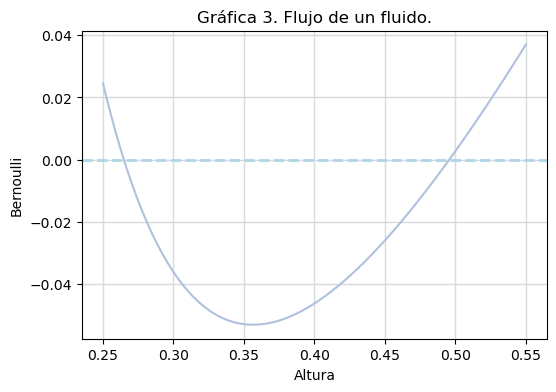

In [12]:
#Graficamos

h=np.linspace(0.25, 0.55, 100)
plt.figure(figsize=(6,4))
plt.plot(h,bernoulli(h),color='#B0C1DE')
plt.axhline(color='#ADD6E6',linestyle='dashed',linewidth = 2) #linea en 0
plt.grid(color = '#D7DBDD',linewidth = 1)
plt.xlabel('Altura')
plt.ylabel('Bernoulli')
plt.title('Gráfica 3. Flujo de un fluido.')

print(busqueda_incremental(bernoulli,0.001,1))
print(secante(bernoulli,0.45,1))

## 4. GUERRA DE MÉTODOS
Determina las raíces de las siguientes funciones con todos los métodos vistos en clase.

###a) Gráfica las funciones para que determines el intervalo a evaluar.

###b) Para cada caso, explica cual es el mejor método y cuál es el peor, así como el error numérico.



1. $x-\cos x=0$ en $(0,\frac{\pi}{2})$
2. $f(x)=\cos x -x^3$ con una valor inicial de $x_0=0.5$
3. $\tan(\pi x)-6=0$ en $(0,1)$\\
4. \begin{equation}
f(x)=\frac{1}{(x-0.3)^2+0.01}-\frac{1}{(x-0.8)^2+0.04}
\end{equation}
5.
$$
f(x)=x^4-6.4x^3+6.45x^2+20.538x-31.752
$$
6. $y =  x^2 − 2x + sin(x)cos(x) - 3$

Nota:  No olvides reportar el error numérico.

In [13]:
#definimos las funciones
f1 = lambda x: x - np.cos(x)
f2 = lambda x: 0.5*np.cos(x) - x**3
f3 = lambda x: np.tan(mth.pi*x) - 6
f4 = lambda x: 1/((x-0.3)**2 + 0.01) - 1/((x-0.8)**2 + 0.04)
f5 = lambda x: x**4 - 6.4*x**3 + 6.45*x**2 + 20.538*x - 31.752
f6 = lambda x: x**2 - 2*x + np.sin(x)*np.cos(x) - 3

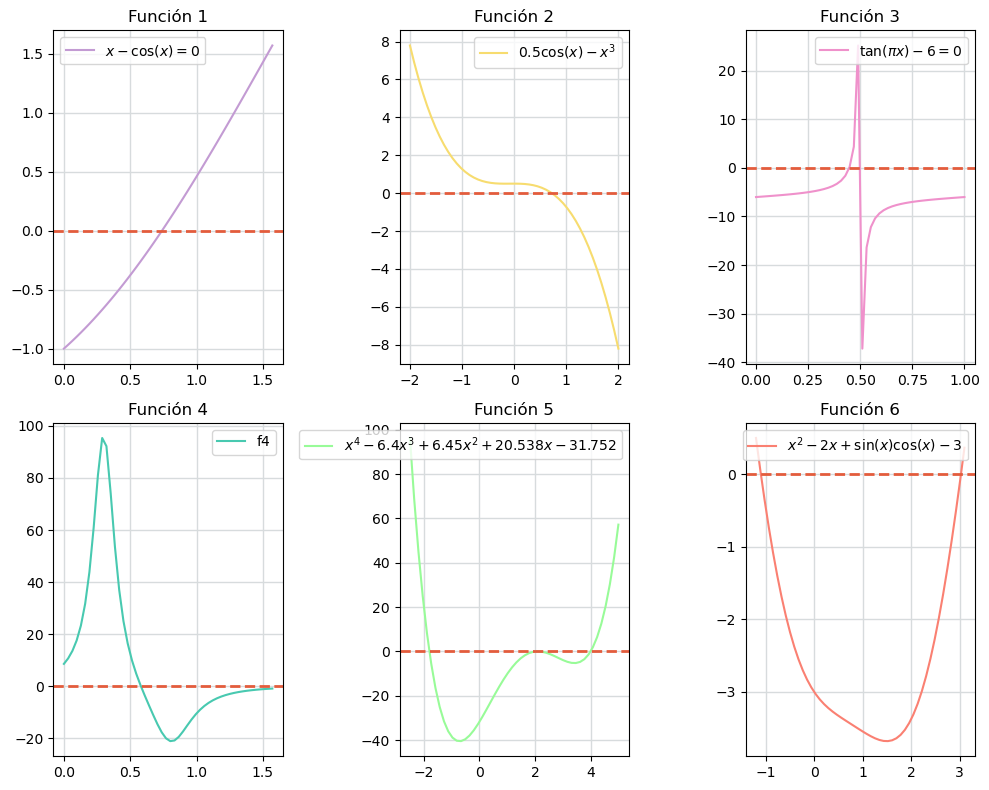

In [14]:
#Definimos los espacios en x

X1 = np.linspace(0,np.pi/2)
X2 = np.linspace(-2,2)
X3 = np.linspace(0,1)
X6 = np.linspace(-1.2,3.1)
X5 = np.linspace(-2.5,5)

fig,axs = plt.subplots(2,3,figsize =(10,8))

# Colores
colors = ['#C39BD3', '#F7DC6F', '#EF91CB', '#48C9B0', '#98FB98', '#FA8072']

# Plotea las gráficas
axs[0, 0].plot(X1,f1(X1),label = r"$x - \cos(x) = 0$", color=colors[0])
axs[0, 1].plot(X2,f2(X2),label = r"$0.5 \cos(x) -x^3 $", color=colors[1])
axs[0, 2].plot(X3,f3(X3),label = r"$\tan(\pi x) - 6 = 0$", color=colors[2])
axs[1, 0].plot(X1,f4(X1),label = 'f4', color=colors[3])
axs[1, 1].plot(X5,f5(X5),label = r'$x^4 - 6.4 x^3 + 6.45 x^2 + 20.538 x - 31.752$', color=colors[4])
axs[1, 2].plot(X6,f6(X6),label = r'$x^2 - 2x + \sin(x)\cos(x) - 3$', color=colors[5])

# Configuración de los títulos y leyendas
for i in range(2):
    for j in range(3):
        axs[i, j].set_title(f'Función {i*3 + j + 1}')
        axs[i, j].legend()
        axs[i, j].grid(color = '#D7DBDD',linewidth = 1)
        axs[i,j].axhline(color='#E35C3C',linestyle='dashed',linewidth = 2)

plt.tight_layout()
plt.show()


In [15]:
#Calculamos las raíces


## 5. TEMPERATURA CRÍTICA

El potencial de un campo escalar real con rompimiento espontáneo de simetría (cf. Mecanismo de Higgs) es
$$
V(\phi) = -\frac{1}{2}m^2\phi^2+\frac{\lambda}{4!}\phi^4,
$$
que tiene la forma de ``sombrero mexicano'' donde hay un mínimo degenerado en $\phi = \pm\sqrt{6m^2/\lambda}$. Este fenómeno (el mínimo ya no está en cero, como pasaría si $m^2\rightarrow -m^2$) está asociado con el rompimiento espontáneo de la simetría. Sin embargo, cuando se toman en cuenta efectos térmicos, la simetría puede ser restaurada (el mínimo puede regresar a $\phi=0$). El potencial con contribuciones térmicas es
\begin{align*}
    V^\beta(\phi) &= -\frac{m^2}{2}\phi^2+\frac{\lambda}{4!}\phi^4+\frac{7\lambda m^2 \phi^2}{128\pi^2}-\frac{3}{4}\frac{\lambda \phi^4}{128\pi^2}-
    \frac{1}{64\pi^2}M^4\left[\ln\left(\frac{2m^2}{16\pi^2 T^2}\right)-\frac{3}{2}+2\gamma_E\right] \\
    &\qquad \qquad -\frac{\pi^2 T^4}{90}+\frac{M^2 T^2}{24}-\frac{M^3_\text{eff}T}{12\pi}-\frac{m^2\lambda(1+\gamma_E)}{32\pi^2}\phi^2+\frac{T\lambda}{16\pi}\phi^2\sqrt{\frac{T^2\lambda}{24}-m^2}-\\
    &\qquad \qquad \frac{m^2\lambda}{64\pi^2}\ln\left(\frac{m^2}{8\pi^2T^2}\right)\phi^2,
\end{align*}
donde $M=(\frac{\lambda}{2}\phi^2-m^2)^{1/2}$, $M_\text{eff}=(M^2+\frac{\lambda T^2}{24})^{1/2}$ y $\gamma_E$ es la Gamma de Euler.

En la Figura se ha graficado $V^\beta(\phi)-V^\beta(0)$. Para temperaturas por encima de $T_1=\sqrt{24m^2/\lambda}$, el potencial es completamente real. Para temperaturas $T_1 < T < T_c$, el mínimo del potencial se va acercando de manera continua al origen. A una temperatura crítica $T_c$, hay un mínimo degenerado en el origen y fuera de él, dando lugar a una transición de fase de primer orden. Por encima de la temperatura crítica $T_c$, el mínimo global se mueve de forma discontinua al origen mostrando la restauración de la simetría. Encuentra la temperatura crítica cuando $\lambda=1$ y  $m^2=600$. (Hint: La temperatura crítica estará cerca de $T_1=120$.)



In [16]:
def Vbeta(phi, T):
    gammaE = 0.57721566490153286060651209  # Euler's constant

    term1 = -600 * phi
    term2 = (525 * phi) / (8 * np.pi**2)
    term3 = -(75 * (1 + gammaE) * phi) / (2 * np.pi**2)
    term4 = (T**2 * phi) / 24
    term5 = (1 / (8 * np.pi)) * T * np.sqrt(-600 + T**2 / 24) * phi
    term6 = phi**3 / 6
    term7 = -(3 * phi**3) / (128 * np.pi**2)
    term8 = -(75 * phi * np.log(75 / (np.pi**2 * T**2))) / (4 * np.pi**2)
    term9 = -phi * (-600 + phi**2 / 2) * (-(3/2) + 2 * gammaE + np.log(75 / (np.pi**2 * T**2))) / (32 * np.pi**2)

    return term1 + term2 + term3 + term4 + term5 + term6 + term7 + term8 + term9


## 6. LAGRANGE

Sea f(x) = 2 sin($\frac{πx}{6}$) (con el ángulo medido en radianes).

a) Usa el polinomio de Lagrangre con nodos x0 = 0, x1 = 1 y x2 = 3 para aproximar f(2) y f(2.4).

b) Usa el polinomio de Lagrangre con nodos x0 = 0, x1 = 1, x2 = 3 y x3 = 5 para aproximar f(2) y f(2.4).

c) Usa el polinomio de Lagrangre con nodos x0 = 0, x1 = 1 y x2 = 3 para aproximar f(4) y f(3.5).

d) Usa el polinomio de Lagrangre con nodos x0 = 0, x1 = 1, x2 = 3 y x3 = 5 para aproximar f(4) y f(3.5).

In [17]:
print('Inciso a')
f = lambda x: 2*np.sin((mth.pi*x)/6)
X1 = [0,1,3]
Y1 = [f(i) for i in X1]

print('Aproximación en x = 2','\n',lagrange(2,X1,Y1),'\n','Valor real de f evaluada en x = 2: ',f(2))

print('Aproximación en x = 2.4','\n',lagrange(2.4,X1,Y1),'\n','Valor real de f evaluada en x = 2.4: ',f(2.4))

print('\n','Inciso b')
X2 = [0,1,3,5]
Y2 = [f(i) for i in X2]

print('Aproximación en x = 2','\n',lagrange(2,X2,Y2),'\n','Valor real de f evaluada en x = 2: ',f(2))

print('Aproximación en x = 2.4','\n',lagrange(2.4,X2,Y2),'\n','Valor real de f evaluada en x = 2.4: ',f(2.4))

print('\n','Inciso c')
X3 = [0,1,3]
Y3 = [f(i) for i in X3]

print('Aproximación en x = 4','\n',lagrange(4,X3,Y3),'\n','Valor real de f evaluada en x = 4: ',f(4))

print('Aproximación en x = 3.5','\n',lagrange(3.5,X3,Y3),'\n','Valor real de f evaluada en x = 3.5: ',f(3.5))

print('\n','Inciso d')
X4 = [0,1,3,5]
Y4 = [f(i) for i in X4]

print('Aproximación en x = 4','\n',lagrange(4,X4,Y4),'\n','Valor real de f evaluada en x = 4: ',f(4))

print('Aproximación en x = 3.5','\n',lagrange(3.5,X4,Y4),'\n','Valor real de f evaluada en x = 3.5: ',f(3.5))

Inciso a
Aproximación en x = 2 
 1.6666666666666665 
 Valor real de f evaluada en x = 2:  1.7320508075688772
Aproximación en x = 2.4 
 1.8399999999999999 
 Valor real de f evaluada en x = 2.4:  1.902113032590307

 Inciso b
Aproximación en x = 2 
 1.7 
 Valor real de f evaluada en x = 2:  1.7320508075688772
Aproximación en x = 2.4 
 1.8736 
 Valor real de f evaluada en x = 2.4:  1.902113032590307

 Inciso c
Aproximación en x = 4 
 2.0 
 Valor real de f evaluada en x = 4:  1.7320508075688774
Aproximación en x = 3.5 
 2.041666666666667 
 Valor real de f evaluada en x = 3.5:  1.9318516525781366

 Inciso d
Aproximación en x = 4 
 1.8 
 Valor real de f evaluada en x = 4:  1.7320508075688774
Aproximación en x = 3.5 
 1.96875 
 Valor real de f evaluada en x = 3.5:  1.9318516525781366


## 7. Más Lagrange
Se desea aproximar la función $f(x)= arctan(x)$ en el intervalo [0, 4]. Los datos que se conocen son:
x = {0, 1, 2, 4} cuyos respectivos valores son f(x) = {0, 0.785, 1.107, 1.325}. Usa el polinomio de Lagrange para aproximar f(3) y f(1.5).

In [18]:
g = lambda x:np.arctan(x)

X5 = [0,1,2,4]
Y5 =[0,0.785,1.107,1.325]

print(lagrange(3,X5,Y5),g(3),
lagrange(1.5,X5,Y5),g(1.5))

1.2067499999999998 1.2490457723982544 0.988828125 0.982793723247329


Text(0.5, 1.0, 'Gráfica 1. Distribución Gaussiana.')

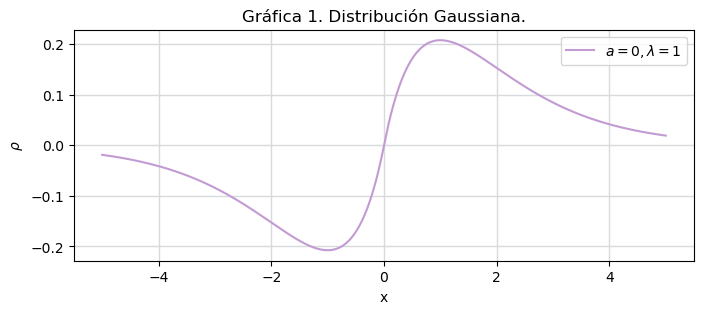

In [27]:
l = [1,1/2,1/4,2]
a = [0,1,-1]
A = lambda i: mth.sqrt(l[i])/mth.sqrt(mth.pi)
f = lambda x,i,j: A(i)*x*np.exp(-l[i]*abs(x-a[j]))
g = lambda x: x*np.exp(-l*x**2)


colors = ['#C39BD3', '#F7DC6F', '#EF91CB', '#48C9B0', '#98FB98', '#FA8072']


h=np.linspace(-5, 5, 300)
plt.figure(figsize=(8,3))
plt.plot(h,f(h,0,0),label=r'$a = 0, \lambda = 1$',color=colors[0])
#plt.plot(h,f(h,1,1),label=r'$a = 1, \lambda = 1/2$',color=colors[1])
#plt.plot(h,f(h,2,2),label=r'$a = -1, \lambda = 1/4$',color=colors[2])
#plt.plot(h,f(h,3,0),label=r'$a = 0, \lambda = 2$',color=colors[3])
plt.grid(color = '#D7DBDD',linewidth = 1)
plt.xlabel('x')
plt.ylabel(r'$\rho$')
plt.legend()
plt.title('Gráfica 1. Distribución Gaussiana.')

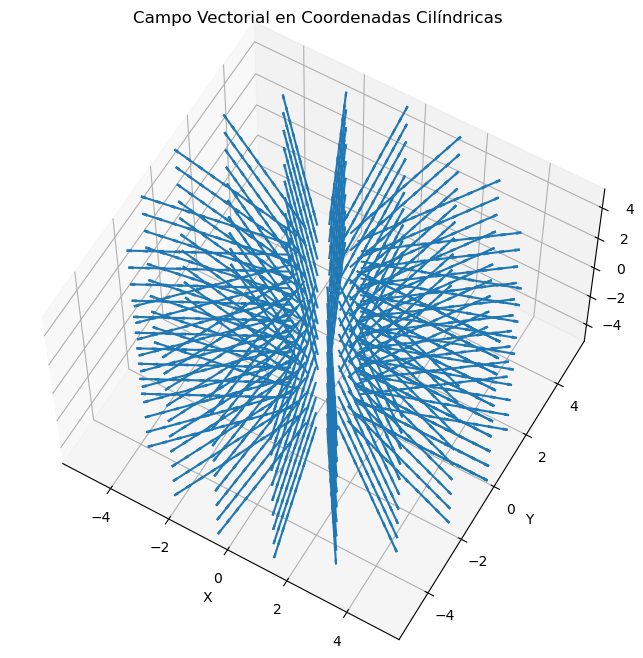

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Definir las funciones Ar, Atheta y Az
def Ar(r, theta, z):
    ke = 1
    sigma = 1
    R = 1
    A = ke*sigma*2*mth.pi
    E = A*np.sqrt(r*(r**2 + R**2)-1)
    return E  # Ejemplo: componente radial

def Atheta(r, theta, z):
    return 0  # Ejemplo: componente azimutal

def Az(r, theta, z):
    return 0  # Ejemplo: componente en la dirección z

# Crear un grid de puntos en coordenadas cilíndricas
r = np.linspace(1, 5, 10)
theta = np.linspace(0, 2 * np.pi, 20)
z = np.linspace(-5, 5, 10)

R, Theta, Z = np.meshgrid(r, theta, z)

# Convertir coordenadas cilíndricas a cartesianas para la visualización
X = R * np.cos(Theta)
Y = R * np.sin(Theta)

# Evaluar el campo vectorial en cada punto
U = Ar(R, Theta, Z) * np.cos(Theta) - Atheta(R, Theta, Z) * np.sin(Theta)
V = Ar(R, Theta, Z) * np.sin(Theta) + Atheta(R, Theta, Z) * np.cos(Theta)
W = Az(R, Theta, Z)

# Crear la figura y el eje 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Visualizar el campo vectorial
ax.quiver(X, Y, Z, U, V, W, length=0.5, normalize=True)

# Configurar las etiquetas de los ejes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Título del gráfico
ax.set_title('Campo Vectorial en Coordenadas Cilíndricas')

# Configurar los ángulos de vista
ax.view_init(elev=60, azim=-60)
# Mostrar el gráfico
plt.show()




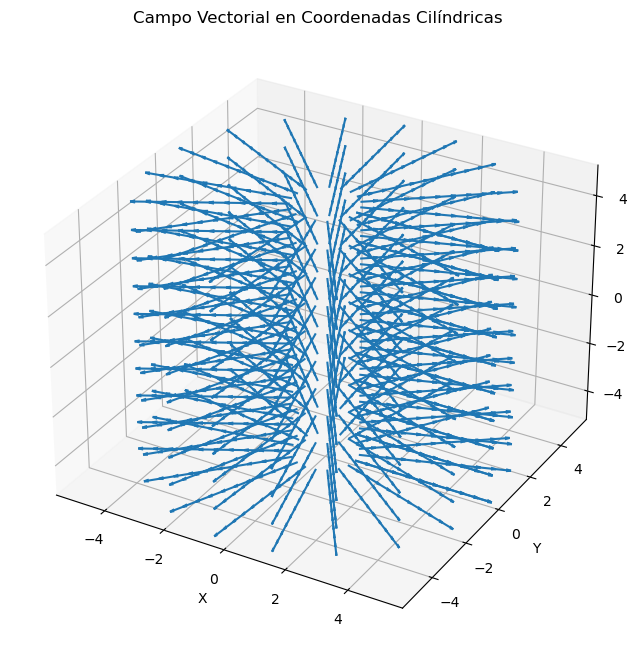

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation

# [El código de la función Ar, Atheta, Az y la creación del grid permanece igual]

# Crear la figura y el eje 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Visualizar el campo vectorial
quiver = ax.quiver(X, Y, Z, U, V, W, length=0.5, normalize=True)

# Configurar las etiquetas de los ejes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Campo Vectorial en Coordenadas Cilíndricas')

# Función de animación para rotar el gráfico
def update(angle):
    ax.view_init(elev=30, azim=angle)
    return quiver,

# Crear la animación
ani = FuncAnimation(fig, update, frames=np.arange(0, 360, 1), interval=50)

plt.show()
